# EDA

### Librerias

In [4]:
import pymysql
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

### Conexión con DB

In [5]:
try:
    conn = pymysql.connect(
        host='212.227.90.6',
        user='Equipo21',
        password= 'E1q2u3i4p5o21',
        database='Equip_21',
    )
    print("✅ Conexión establecida con PyMySQL")
except Exception as e:
    print("❌ Error:", e)

✅ Conexión establecida con PyMySQL


In [6]:
query= "SHOW TABLES"

df=pd.read_sql(query,conn)

df

C:\Users\GPSantana\AppData\Local\Temp\ipykernel_3656\3889364871.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


,Tables_in_Equip_21
0,BANK_marketing


In [7]:
query = "SELECT * FROM BANK_marketing"

df = pd.read_sql(query, conn)

conn.close()

C:\Users\GPSantana\AppData\Local\Temp\ipykernel_3656\4031327985.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


## Resumen del Bloque 1 y 2

### Calidad de los Datos
El análisis inicial muestra que el dataset presenta una estructura consistente, con variables numéricas y categóricas correctamente definidas. Se detectan valores duplicados (10 registros) y valores nulos en *age* (11 registros), los cuales deberán considerarse en etapas posteriores del análisis.

### Estadísticas Descriptivas
Las estadísticas descriptivas evidencian una alta variabilidad en algunas variables numéricas, especialmente en aquellas relacionadas con el *balance* y la *duración*, lo que sugiere la posible presencia de valores extremos en el conjunto de datos. 

### Limitaciones Iniciales
En las variables categóricas se observa la presencia de valores *"unknown"* en campos como *poutcome* (8184 unknown) antes (7886), *contact* (2299) antes (2197), *education* (494) antes (473) y *job* (70) antes (68) y *marital* (5) antes (0). Y también podemos observar que la columna *pdays* cuenta con (8182) registros en (-1) que suele indicar que el cliente no ha sido contactado. Estos datos representan una modificación en los valores iniciales y deberán ser tratados o evaluados según los objetivos del análisis.


## 1. DATA QUALITY - resúmenes estadísticos de las variables

In [ ]:
# Dimensiones del dataset
df.shape

(10998, 18)

In [9]:
df.head()

,id,age,job,marital,education,credit_default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1
1,2,59.0,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1
2,3,56.0,admin.,married,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,unknown,1
3,4,41.0,technician,married,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,unknown,1
4,5,55.0,services,married,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,unknown,1


In [10]:
# Info general del dataset y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10998 entries, 0 to 10997
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              10998 non-null  int64  
 1   age             10987 non-null  float64
 2   job             10998 non-null  object 
 3   marital         10998 non-null  object 
 4   education       10998 non-null  object 
 5   credit_default  10998 non-null  int64  
 6   balance         10998 non-null  int64  
 7   housing         10998 non-null  int64  
 8   loan            10998 non-null  int64  
 9   contact         10998 non-null  object 
 10  day             10998 non-null  int64  
 11  month           10998 non-null  object 
 12  duration        10998 non-null  int64  
 13  campaign        10998 non-null  int64  
 14  pdays           10998 non-null  int64  
 15  previous        10998 non-null  int64  
 16  poutcome        10998 non-null  object 
 17  deposit         10998 non-null 

In [ ]:
# Info de filas duplicadas

df.duplicated().sum()

np.int64(10)

#### 1.2 resumen variables numericas

In [29]:
numeric_cols = df.select_dtypes(include="number").columns.difference(["id"])

global_numeric_stats = df[numeric_cols].describe().T

global_numeric_stats

,count,mean,std,min,25%,50%,75%,max
age,10987.0,41.259215,11.951895,18.0,32.00,39.0,49.0,95.0
balance,10998.0,1537.195217,3238.607410,-6847.0,125.25,556.0,1721.5,81204.0
campaign,10998.0,2.504455,2.724094,1.0,1.00,2.0,3.0,63.0
credit_default,10998.0,0.014639,0.120108,0.0,0.00,0.0,0.0,1.0
day,10998.0,15.649936,8.423393,1.0,8.00,15.0,22.0,31.0
deposit,10998.0,0.481269,0.499672,0.0,0.00,0.0,1.0,1.0
duration,10998.0,374.191944,348.425873,2.0,139.00,257.0,501.0,3881.0
housing,10998.0,0.471995,0.499238,0.0,0.00,0.0,1.0,1.0
loan,10998.0,0.130296,0.336645,0.0,0.00,0.0,0.0,1.0
pdays,10998.0,51.640935,109.003399,-1.0,-1.00,-1.0,39.5,854.0


#### 1.3 resumen variables categóricas

In [12]:
def resumen_variables_categoricas(dataframe):
    """
    Genera un resumen de variables categóricas:
    - número de categorías
    - valor más frecuente
    - porcentaje del valor más frecuente
    """
    categorical_columns = dataframe.select_dtypes(
        include=["object", "category"]
    ).columns

    resumen_categorico = []

    total_rows = len(dataframe)

    for column in categorical_columns:
        value_counts = dataframe[column].value_counts(dropna=False)

        most_frequent_value = value_counts.index[0]
        most_frequent_percentage = (value_counts.iloc[0] / total_rows) * 100
        unique_categories = dataframe[column].nunique(dropna=False)

        resumen_categorico.append({
            "variable": column,
            "unique_categories": unique_categories,
            "most_frequent_value": most_frequent_value,
            "most_frequent_percentage": round(most_frequent_percentage, 2)
        })

    resumen_categorico_df = pd.DataFrame(resumen_categorico)

    return resumen_categorico_df

In [13]:
# Aplico resumen_variables_categoricas a df
categorical_summary = resumen_variables_categoricas(df)

categorical_summary

,variable,unique_categories,most_frequent_value,most_frequent_percentage
0,job,12,management,23.06
1,marital,4,married,56.78
2,education,4,secondary,49.05
3,contact,3,cellular,72.15
4,month,12,may,25.19
5,poutcome,4,unknown,74.41


## 2. LIMITATIONS - valores nulos y unkwown

#### 2.1 missing data

In [14]:
def resumen_missing_data(dataframe):
    """
    Genera un resumen de valores missing por columna
    """
    # Conteo de valores nulos por columna
    missing_count = dataframe.isna().sum()

    # Porcentaje de valores nulos
    missing_percentage = ((missing_count / len(dataframe)) * 100).round(2)

    # Crear DataFrame resumen (DataFrame con D mayúscula)
    missing_summary_df = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percentage": missing_percentage
    }).sort_values(
        by="missing_percentage",
        ascending=False
    )

    return missing_summary_df

In [15]:
# aplicar resumen_missing_data dataset 
missing_summary = resumen_missing_data(df)

missing_summary

,missing_count,missing_percentage
age,11,0.1
id,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
credit_default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0


#### 2.2 valores unknown

In [26]:
def resumen_unknown_values(dataframe):
    """
    Cuenta valores 'unknown' por columna
    """
    unknown_count = (dataframe == "unknown").sum()

    unknown_summary_df = (
        unknown_count[unknown_count > 0]
        .to_frame(name="unknown_count")
        .sort_values(by="unknown_count", ascending=False)
    )

    return unknown_summary_df

In [17]:
# aplicar resumen_unknown_values a df
unknown_summary = resumen_unknown_values(df)
unknown_summary

,unknown_count
poutcome,8184
contact,2299
education,494
job,70
marital,5


## 3. DISTRIBUTIONS - gráficos de distribución de datos

#### 3.1 Visualicacion de datos numericos

In [18]:
def auto_visualize_dataframe_histplot(df):    
    for column in df.columns:
        
        if pd.api.types.is_numeric_dtype(df[column]):
            plt.figure(figsize=(10, 5))
            sns.histplot(df[column], kde=True)
            plt.title(f"Distribución {column}")
            plt.xlabel(column)
            plt.ylabel("Frecuencia")

            median = df[column].median()
            plt.axvline(median, color="green", linestyle="-", label=f"Median: {median:.1f}")

            mean = df[column].mean()
            plt.axvline(mean, color="red", linestyle="--", label=f"Mean: {mean:.1f}")
            
            plt.show()

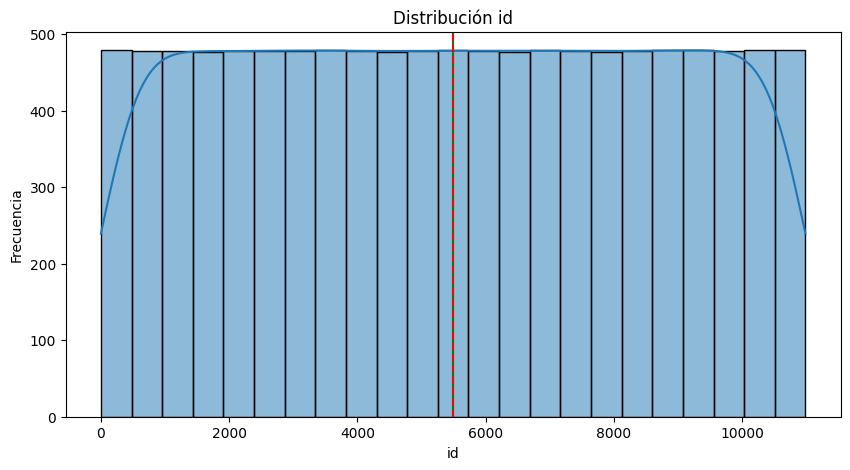

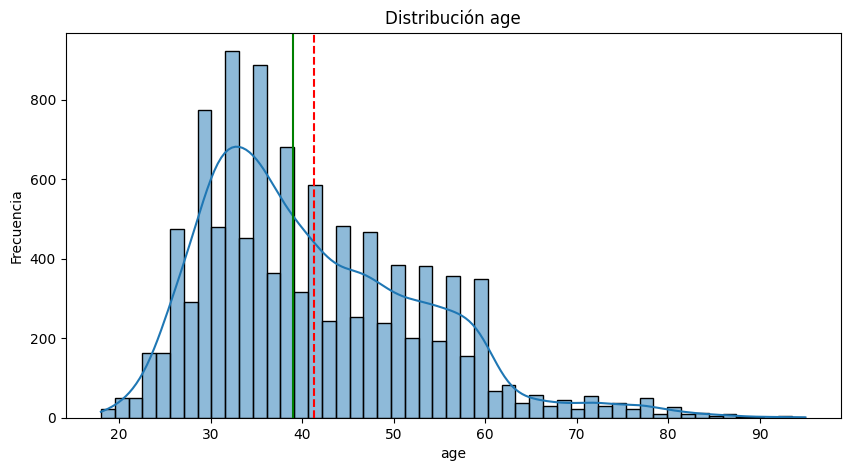

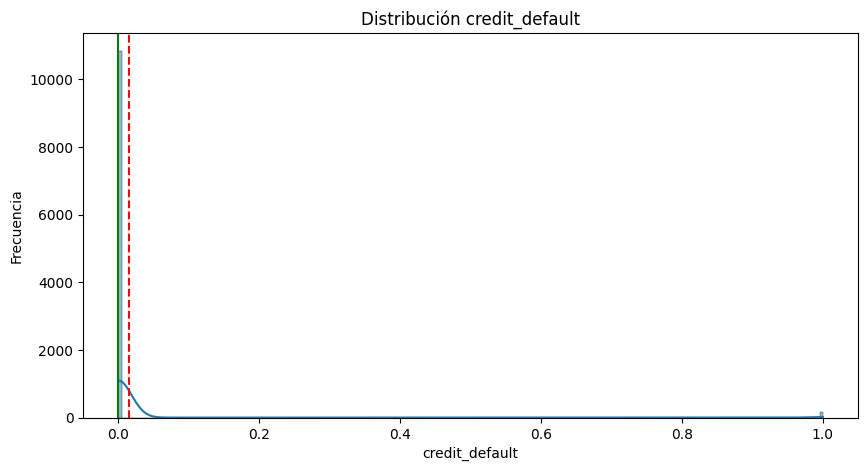

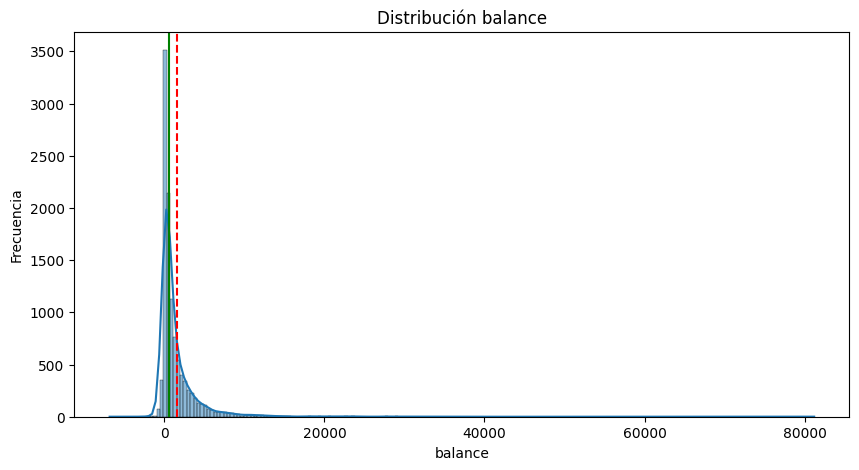

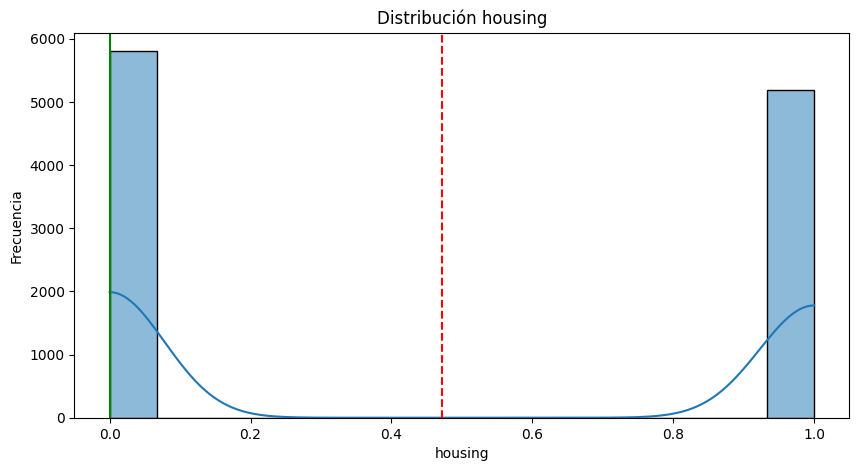

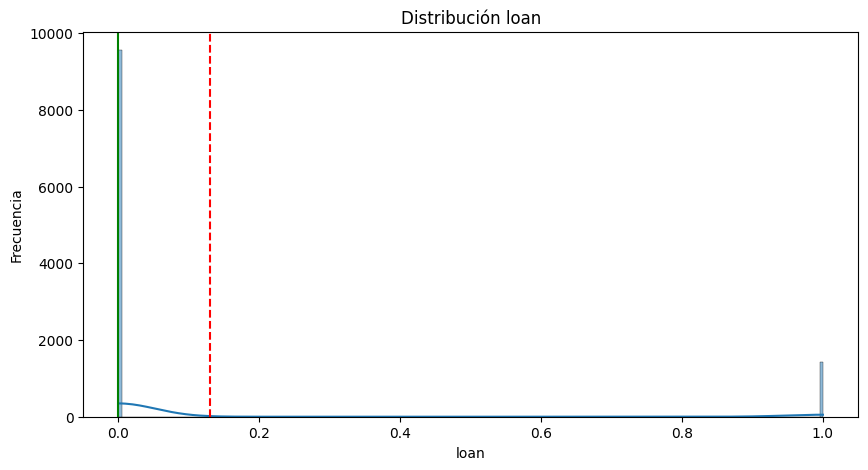

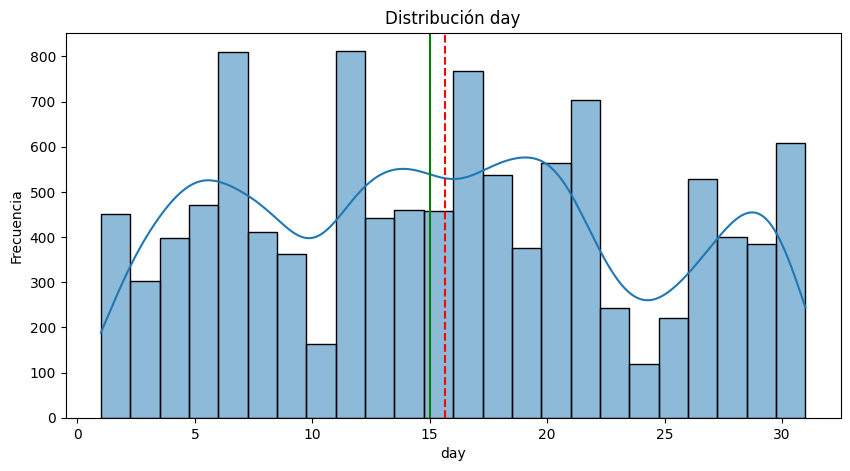

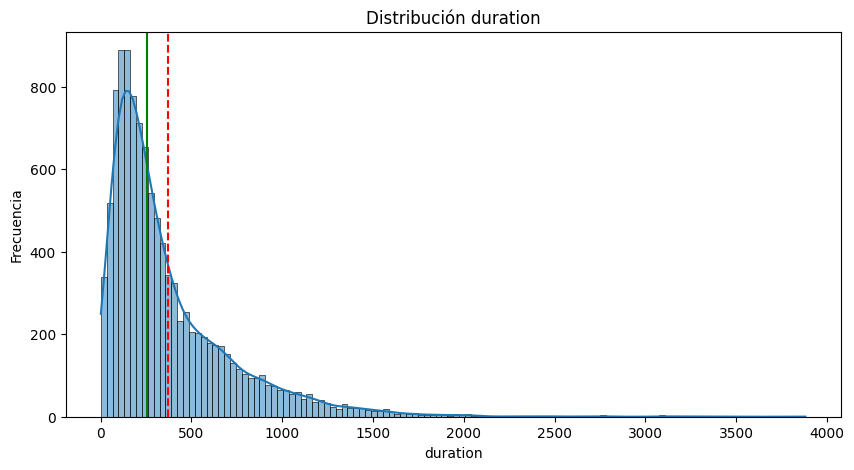

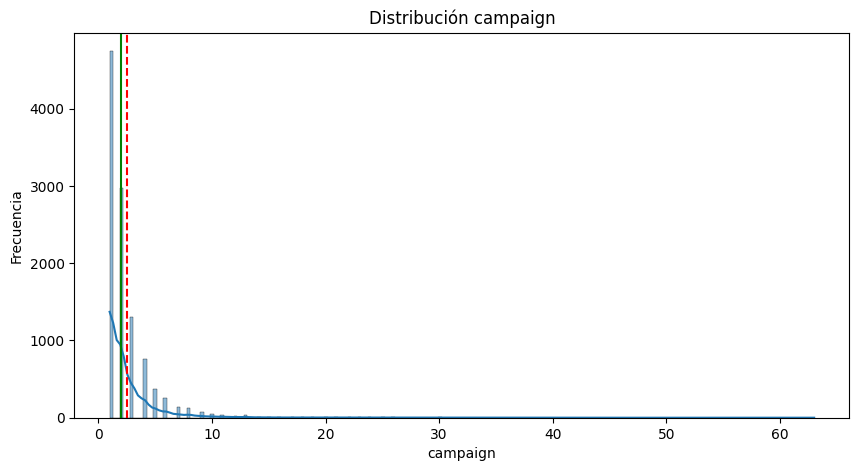

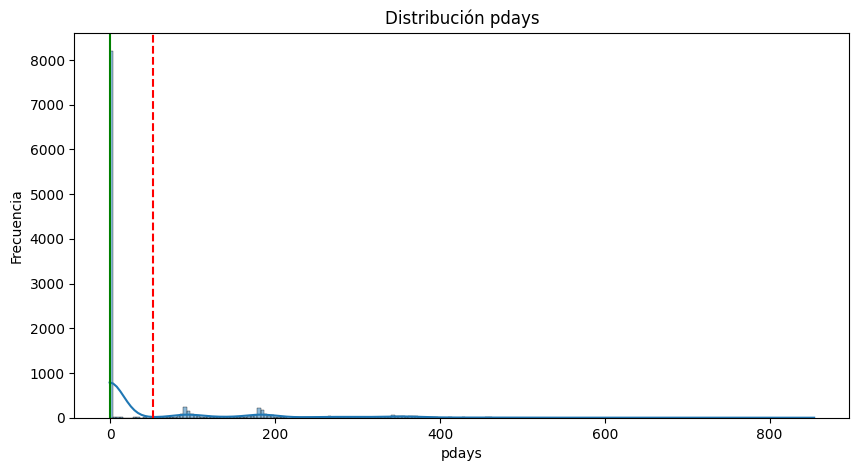

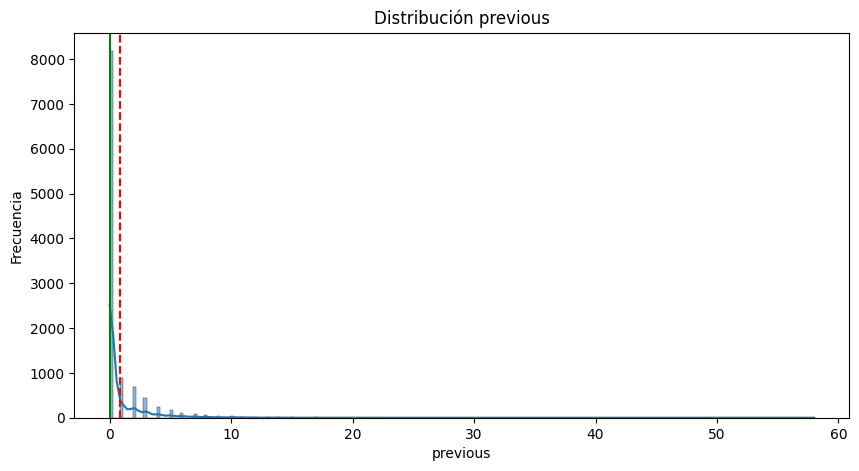

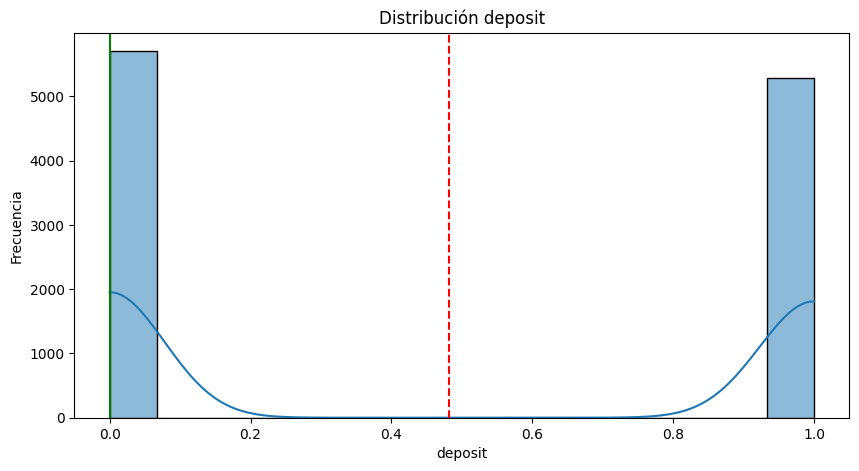

In [19]:
histogramas = auto_visualize_dataframe_histplot(df) 

histogramas

In [34]:
def plot_categorical_distribution(df, exclude=None):
    if exclude is None:
        exclude = []
    
    cat_cols = df.select_dtypes(include='object').columns
    cat_cols = [col for col in cat_cols if col not in exclude]

    for col in cat_cols:
        percentages = df[col].value_counts(normalize=True) * 100

        plt.figure()
        plt.bar(percentages.index.astype(str), percentages.values)
        plt.title(f'Distribución porcentual de {col}')
        plt.ylabel('Porcentaje (%)')
        plt.xlabel(col)
        plt.xticks(rotation=45)
        plt.show()

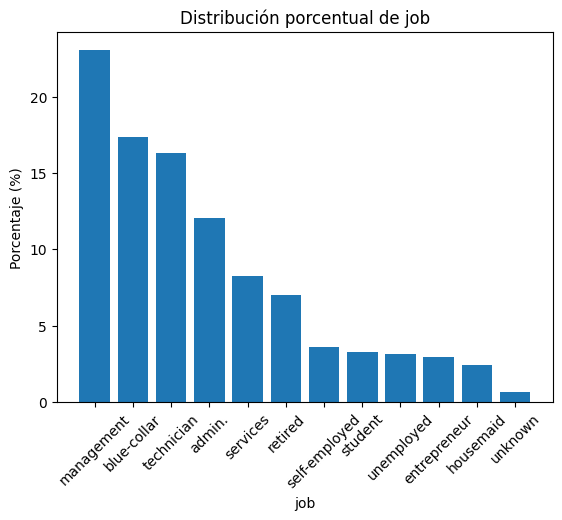

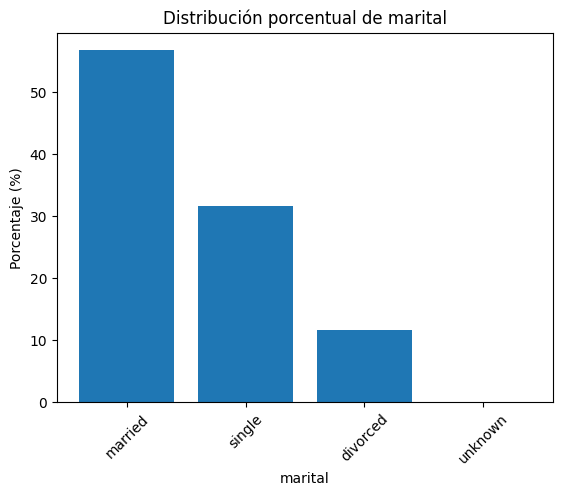

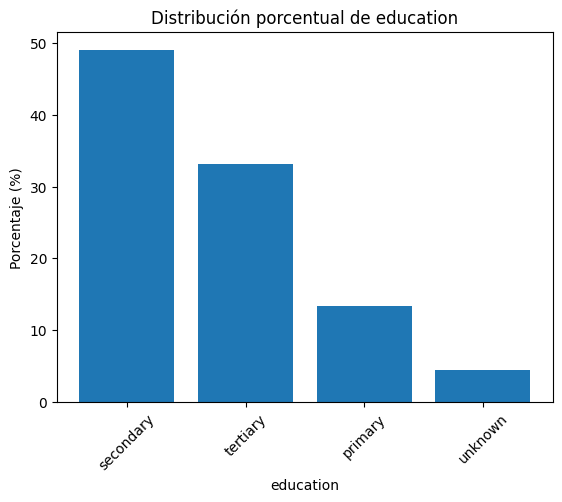

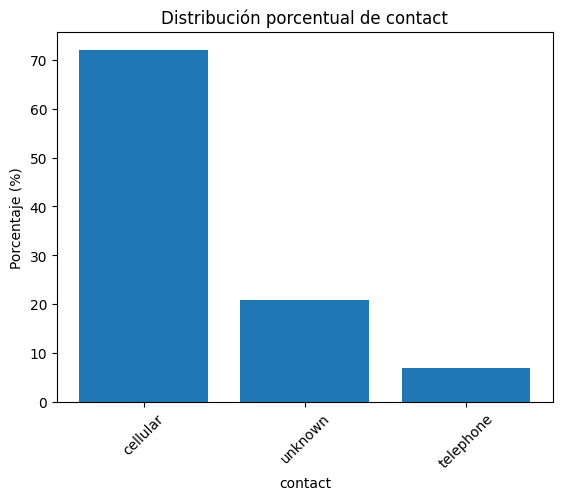

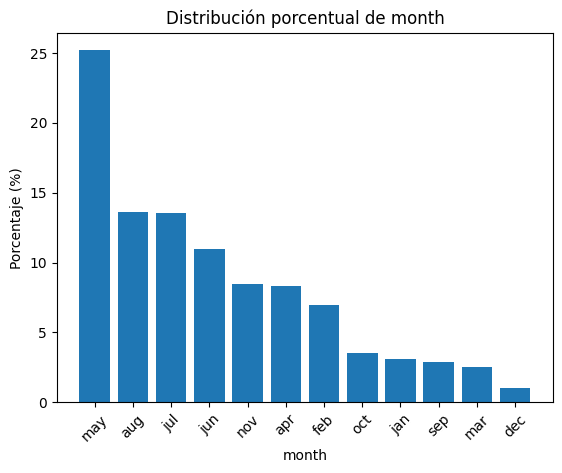

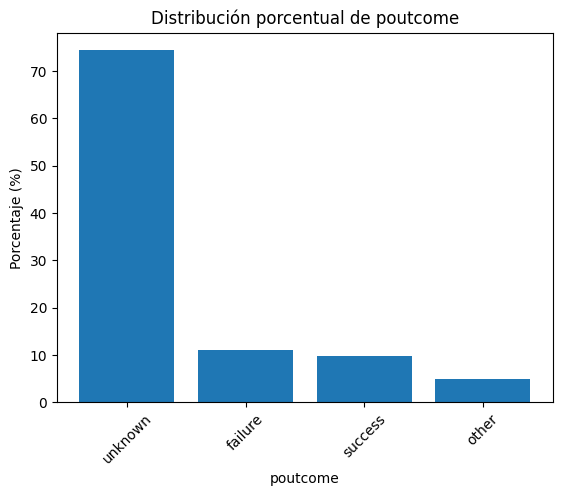

In [35]:
plot_categorical_distribution(df)

In [ ]:
# Distribución deposit

df['deposit'].value_counts(normalize=True) * 100


deposit
0    51.873068
1    48.126932
Name: proportion, dtype: float64

In [ ]:
# Relación entre variables y deposit

def plot_categorical_vs_target(df, target, exclude=None, max_categories=10):
    if exclude is None:
        exclude = []

    cat_cols = df.select_dtypes(include='object').columns
    cat_cols = [col for col in cat_cols if col not in exclude]

    for col in cat_cols:
        if df[col].nunique() > max_categories:
            continue

        ct = pd.crosstab(df[col], df[target], normalize='index') * 100

        ct.plot(kind='bar')
        plt.title(f'{col} vs {target} (%)')
        plt.ylabel('Porcentaje (%)')
        plt.xlabel(col)
        plt.xticks(rotation=45)
        plt.legend(title=target)
        plt.show()

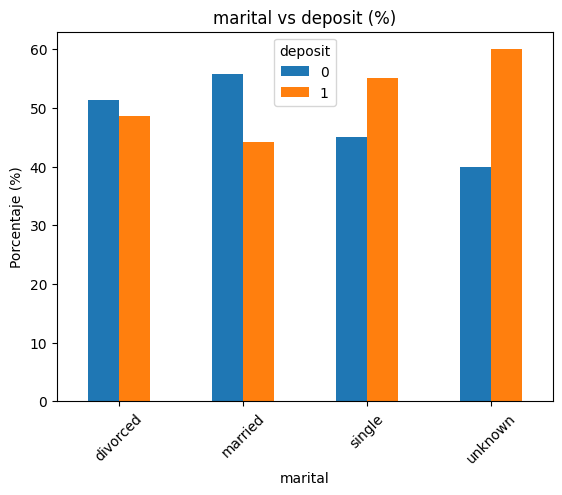

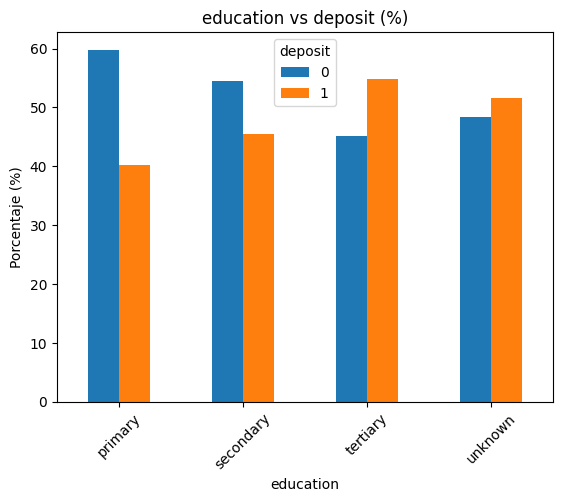

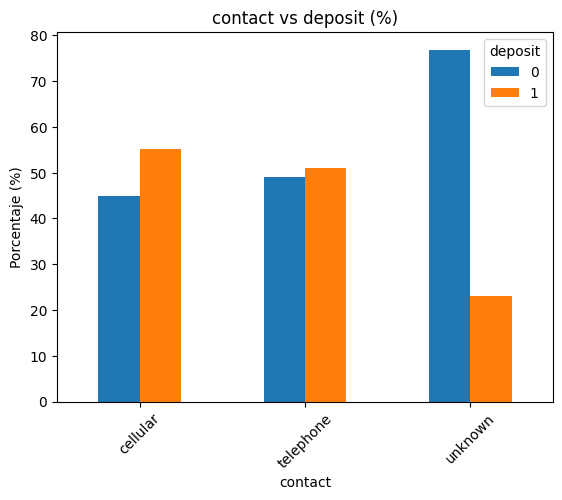

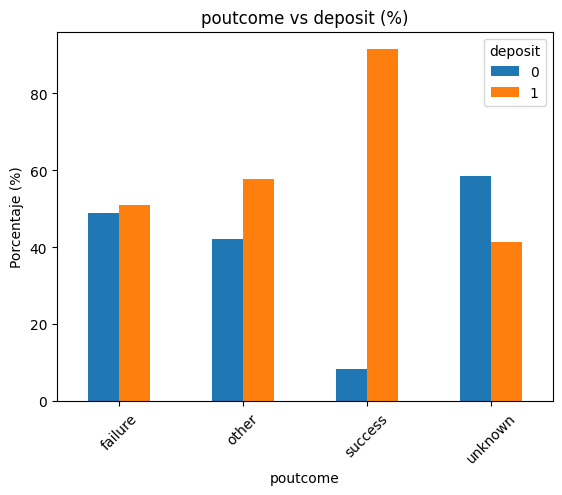

In [39]:
plot_categorical_vs_target(df, target='deposit')


In [43]:
df['pdays'].value_counts().head(100)


pdays
-1      8182
 92      106
 182      89
 91       84
 181      82
        ... 
 1         8
 168       8
 330       7
 150       7
 367       7
Name: count, Length: 100, dtype: int64